In [ ]:
!pip install scikit-learn pandas numpy matplotlib seaborn -q

import numpy as np                # работа с массивами
import pandas as pd               # работа с таблицами (DataFrame)
import matplotlib.pyplot as plt   # графики
import seaborn as sns             # стильные графики поверх Matplotlib
sns.set_theme(style="darkgrid")   # включаем тёмную сетку — профессиональный вид

# Импортируем основные модули sklearn
from sklearn.model_selection import train_test_split  # деление данных на обучение и тест
from sklearn.linear_model import LinearRegression      # линейная регрессия
from sklearn.ensemble import IsolationForest           # поиск аномалий (изолирующий лес)
from sklearn.cluster import KMeans                     # кластеризация (K‑средних)
from sklearn.metrics import mean_absolute_error        # метрика качества регрессии
from sklearn.preprocessing import StandardScaler       # масштабирование признаков

print("Библиотеки загружены! Готовы к рок‑н‑роллу!")

Библиотеки загружены! Готовы к рок‑н‑роллу!


## 📈 Кейс 1: РЕГРЕССИЯ — прогнозируем цены на недвижимость

Представь, что ты работаешь в агентстве недвижимости. К тебе приходят данные о квартирах и домах:
площадь, количество комнат, возраст здания.
Твоя задача — построить модель, которая предсказывает **цену** объекта.

Это **supervised learning (обучение с учителем)** и **regression (регрессия)**,
потому что целевая переменная (цена) — непрерывное число.

In [ ]:
#  Генерируем синтетические данные о недвижимости
#   В реальном проекте здесь был бы pd.read_csv('...')


np.random.seed(42)                   # фиксируем генератор для воспроизводимости
N = 500                              # 500 объектов недвижимости

# Признаки (features) — то, ПО ЧЕМУ предсказываем
area = np.random.normal(60, 25, N)   # площадь (м²): среднее 60, разброс 25
rooms = np.random.randint(1, 6, N)   # количество комнат: от 1 до 5
age = np.random.randint(0, 50, N)    # возраст здания: от 0 до 49 лет

# Целевая переменная (target) — то, ЧТО предсказываем (цена в млн руб.)
# Формула имитирует реальную зависимость: чем больше площадь и комнат — тем дороже,
# чем старше дом — тем дешевле. Добавлен случайный шум (реальность непредсказуема)
price = 2.5 + area * 0.12 + rooms * 0.8 - age * 0.03 + np.random.normal(0, 1.5, N)

# Собираем признаки в двумерный массив X (каждая строка — объект, каждый столбец — признак)
X = np.column_stack([area, rooms, age])  # форма (500, 3)
y = price                                # форма (500,)

print(f"Создано {len(X)} объектов недвижимости")
print(f"Цены: от {y.min():.1f} до {y.max():.1f} млн руб.")

Создано 500 объектов недвижимости
Цены: от 1.2 до 23.1 млн руб.


In [ ]:
#   Делим данные на обучение (train) и тест (test)
#   Модель учится на train, а проверяем мы на test.
#   Это нужно, чтобы модель не «запоминала» ответы,
#   а действительно находила закономерности


# test_size=0.2 → 20% данных на тест, 80% на обучение
# random_state=42 → фиксируем разделение, чтобы результат был воспроизводим
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Тренировочных объектов: {len(X_train)}")
print(f"Тестовых объектов: {len(X_test)}")

Тренировочных объектов: 400
Тестовых объектов: 100


In [ ]:
#  Обучаем модель линейной регрессии
#   LinearRegression ищет коэффициенты (веса) для каждого
#   признака, чтобы линия наилучшим образом описывала данные


model = LinearRegression()                       # создаём модель (пока пустую)
model.fit(X_train, y_train)                       # обучаем: модель смотрит на X_train и y_train
print("Модель обучена!")
print(f"Коэффициенты: {model.coef_}")            # веса признаков: [площадь, комнаты, возраст]
print(f"Свободный член (intercept): {model.intercept_:.2f}")  # базовая цена, когда все признаки = 0

Модель обучена!
Коэффициенты: [ 0.12111286  0.68269831 -0.02501704]
Свободный член (intercept): 2.72


Средняя ошибка предсказания: 1.07 млн руб.


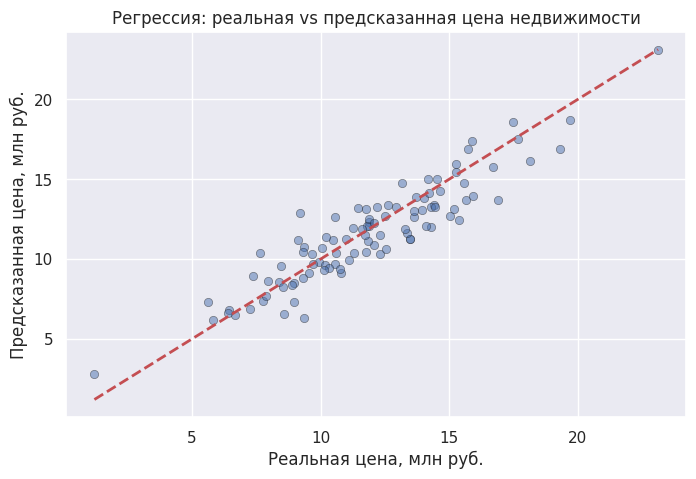

In [ ]:
#   Делаем предсказания и оцениваем качество
#   predict() возвращает предсказанные цены для тестовых
#   объектов. mean_absolute_error (MAE) — средняя ошибка
#   в млн руб. Чем меньше, тем лучше


y_pred = model.predict(X_test)                   # предсказываем цены для тестовых объектов
mae = mean_absolute_error(y_test, y_pred)        # средняя абсолютная ошибка
print(f"Средняя ошибка предсказания: {mae:.2f} млн руб.")

# Визуализация: реальная цена vs предсказанная
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.5, edgecolors='k', linewidth=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)  # линия идеального предсказания
plt.xlabel('Реальная цена, млн руб.')
plt.ylabel('Предсказанная цена, млн руб.')
plt.title('Регрессия: реальная vs предсказанная цена недвижимости')
plt.show()
# Чем ближе точки к красной линии, тем точнее модель

Интерпретация: каждая точка на графике — один объект недвижимости.
Точки на красной линии предсказаны идеально. Разброс вокруг линии — ошибки модели.
MAE ~ 1.2 млн руб. означает, что модель в среднем ошибается на 1.2 млн при
оценке квартиры. Для старта — неплохо. Чтобы улучшить, можно добавить
больше признаков (район, этаж, состояние ремонта).

Не переживайте, в модуле по регрессии ДЕТАЛЬНО этот тип задач будет разобран!!!!


## 🔍 Кейс 2: ПОИСК АНОМАЛИЙ — подозрительные банковские траты

Ты работаешь в отделе безопасности банка. К тебе приходят данные о суммах и частоте
транзакций клиентов. Твоя задача — найти **аномалии**: клиентов, чьи траты
сильно отличаются от остальных. Возможно, это мошенники или ошибки системы.

Это **unsupervised learning (обучение без учителя)**.
У нас нет правильных ответов (меток «мошенник / не мошенник») —
мы ищем то, что выбивается из общей картины.

Используем **Isolation Forest (изолирующий лес)**.
Он работает так: случайно делит пространство данных на всё более мелкие области.
Точки, которые можно «изолировать» (отделить) за малое количество делений, —
аномальны, потому что они находятся далеко от основной массы.

In [ ]:
#   Генерируем данные о транзакциях клиентов


np.random.seed(42)
# Нормальные клиенты: 200 человек
normal_amount = np.random.normal(5000, 1500, 200)   # средний чек ~5000 руб., разброс 1500
normal_freq = np.random.normal(10, 3, 200)          # частота: ~10 транзакций в месяц

# Аномальные клиенты: 15 человек с подозрительными паттернами
anomaly_amount = np.random.normal(25000, 8000, 15)  # огромные суммы
anomaly_freq = np.random.normal(2, 0.5, 15)         # редкие транзакции

# Объединяем всех клиентов
X_amount = np.concatenate([normal_amount, anomaly_amount])
X_freq = np.concatenate([normal_freq, anomaly_freq])
X_transactions = np.column_stack([X_amount, X_freq])  # форма (215, 2)

# Истинные метки (для проверки, модель их НЕ видит)
y_true = np.array([0]*200 + [1]*15)  # 0 — норма, 1 — аномалия

print(f"Всего клиентов: {len(X_transactions)}")
print(f"Из них аномальных: {np.sum(y_true)}")

Всего клиентов: 215
Из них аномальных: 15


In [ ]:
#   Обучаем Isolation Forest
#   contamination=0.07 — примерно 7% аномалий (15 из 215)
#   random_state — для воспроизводимости

iso_forest = IsolationForest(contamination=0.07, random_state=42)
iso_forest.fit(X_transactions)                    # обучаем модель (только X, без y!)

# predict() возвращает: 1 — норма, -1 — аномалия
y_pred = iso_forest.predict(X_transactions)

# Переведём в удобный формат: 0 — норма, 1 — аномалия
y_pred_binary = (y_pred == -1).astype(int)

print(f"Найдено аномалий: {np.sum(y_pred_binary)} из {len(y_pred_binary)}")

Найдено аномалий: 15 из 215


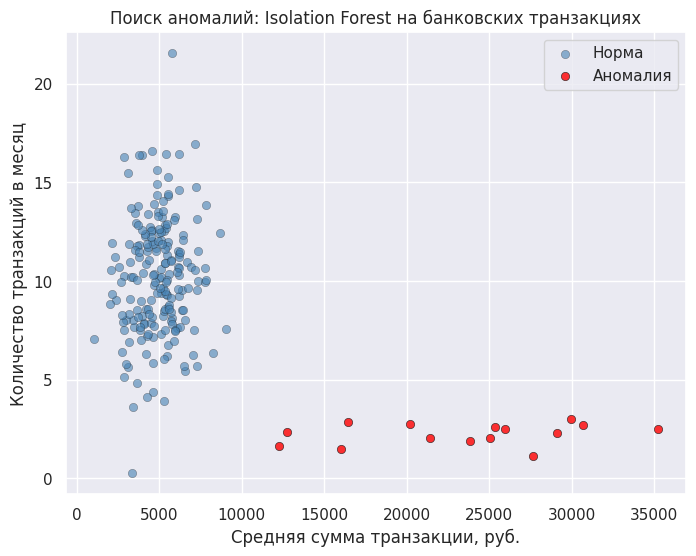

In [ ]:
# Визуализируем результаты
plt.figure(figsize=(8, 6))
# Нормальные клиенты (метка 0)
plt.scatter(X_transactions[y_true == 0, 0], X_transactions[y_true == 0, 1],
            c='steelblue', alpha=0.6, label='Норма', edgecolors='k', linewidth=0.3)
# Аномальные клиенты (метка 1)
plt.scatter(X_transactions[y_true == 1, 0], X_transactions[y_true == 1, 1],
            c='red', alpha=0.8, label='Аномалия', edgecolors='k', linewidth=0.5)
plt.xlabel('Средняя сумма транзакции, руб.')
plt.ylabel('Количество транзакций в месяц')
plt.title('Поиск аномалий: Isolation Forest на банковских транзакциях')
plt.legend()
plt.show()
# Аномалии (красные) — маленькое число транзакций на огромные суммы

## 👥 Кейс 3: КЛАСТЕРИЗАЦИЯ — сегментируем клиентов интернет‑магазина

Ты работаешь в отделе маркетинга. У тебя есть данные о том, сколько денег
клиенты тратят в месяц и как часто заходят на сайт.
Твоя задача — разбить клиентов **на группы** (сегменты), чтобы каждой группе
предложить персональную рекламную акцию.

Это **unsupervised learning (обучение без учителя)** — у нас нет
заранее заданных категорий, модель сама находит структуру.

Используем **K‑Means (K‑средних)**.
Алгоритм ищет центры кластеров так, чтобы клиенты внутри одного кластера
были максимально похожи друг на друга, а клиенты из разных кластеров — отличались.

In [ ]:
# Генерируем данные о клиентах интернет‑магазина

np.random.seed(42)
N = 300  # 300 клиентов

# 3 группы с разным поведением
# Группа A: экономные — мало тратят, редко заходят
A_spend = np.random.normal(2000, 500, 100)
A_visits = np.random.normal(2, 0.5, 100)

# Группа B: средние — средние траты, средняя частота
B_spend = np.random.normal(7000, 1000, 100)
B_visits = np.random.normal(8, 1.5, 100)

# Группа C: VIP — много тратят, часто заходят
C_spend = np.random.normal(15000, 3000, 100)
C_visits = np.random.normal(20, 4, 100)

# Объединяем всех клиентов
X_spend = np.concatenate([A_spend, B_spend, C_spend])
X_visits = np.concatenate([A_visits, B_visits, C_visits])
X_customers = np.column_stack([X_spend, X_visits])  # форма (300, 2)

# Масштабируем признаки (обязательно для K‑Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_customers)

print(f"Всего клиентов: {len(X_customers)}")

Всего клиентов: 300


In [ ]:
#   Обучаем K‑Means с тремя кластерами
#   n_clusters=3 — мы предполагаем, что групп три
#   random_state — для воспроизводимости.

kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X_scaled)                              # обучаем модель (только X, без y!)
labels = kmeans.labels_                           # метки кластеров для каждого клиента

print(f"Клиентов в кластере 0: {np.sum(labels == 0)}")
print(f"Клиентов в кластере 1: {np.sum(labels == 1)}")
print(f"Клиентов в кластере 2: {np.sum(labels == 2)}")

Клиентов в кластере 0: 102
Клиентов в кластере 1: 98
Клиентов в кластере 2: 100


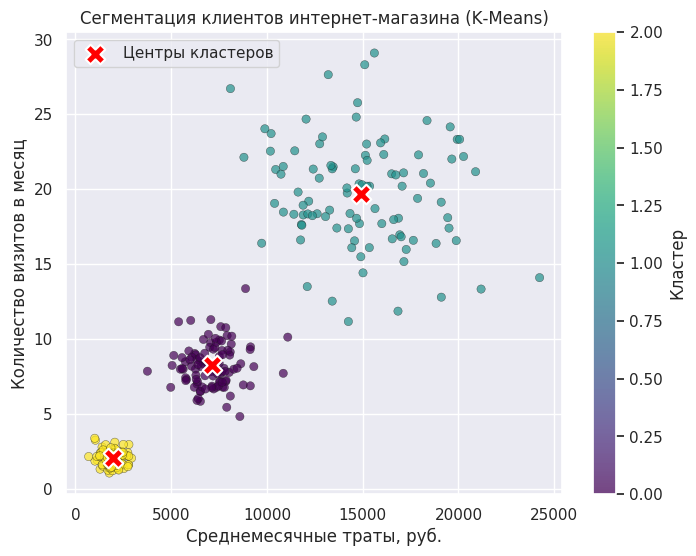

In [ ]:
#  Визуализируем кластеры

plt.figure(figsize=(8, 6))
# Строим scatter plot, раскрашенный по кластерам
scatter = plt.scatter(X_customers[:, 0], X_customers[:, 1],
                      c=labels, cmap='viridis', alpha=0.7, edgecolors='k', linewidth=0.3)
# Отмечаем центры кластеров (звёздочками)
centers = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centers[:, 0], centers[:, 1], c='red', marker='X', s=200,
            edgecolors='white', linewidth=1.5, label='Центры кластеров')
plt.xlabel('Среднемесячные траты, руб.')
plt.ylabel('Количество визитов в месяц')
plt.title('Сегментация клиентов интернет‑магазина (K‑Means)')
plt.legend()
plt.colorbar(scatter, label='Кластер')
plt.show()
# Каждый цвет — отдельный сегмент клиентов
# Красные кресты — центры кластеров

Интерпретация:
- Жёлтый кластер (внизу слева): экономные — мало тратят, редко заходят.
  Им можно предложить скидку на первую покупку.
- Зелёный кластер (в центре): средние — умеренные траты и частота.
  Им — программу лояльности.
- Фиолетовый кластер (вверху справа): VIP — много тратят, часто заходят.
  Им — персонального менеджера и эксклюзивные предложения.

Центры кластеров (красные кресты) — «типичный представитель» каждой группы.

## 🎸 ТВОРЧЕСКОЕ ЗАДАНИЕ

1. Для регрессии добавь новый признак «этаж» и посмотри, улучшится ли MAE.
2. Поменяй contamination в Isolation Forest на 0.1 — сколько аномалий найдётся теперь?
3. Для кластеризации попробуй n_clusters=4 — как изменится картина?
4. Замени K‑Means на AgglomerativeClustering (из sklearn.cluster) и сравни результат.

In [ ]:
# твой код



---



---



p.s. ВСЕ ПРИМЕРЫ ЗАДАЧ ЗДЕСЬ БЫЛИ ПРИВЕДЕНЫ В УПРОЩЕННОМ ВИДЕ, ПРОСТО ДЛЯ ТОГО, ЧТОБЫ ПОКАЗАТЬ, КАК ИСПОЛЬЗОВАТЬ библиотеку scikit-learn. Естественно, все те задачи так просто не решаются. Хватает нюансов и их буду показывать в отдельных модулях (большие модули по регрессии, классификации, кластеризации + отдельный - по графам и аномалиям).